In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

import covid19_inference.covid19_inference as cov19
import utils

# increase plt fontsize
plt.rcParams.update({'font.size': 20})

from matplotlib import lines, patches

In [2]:
# colormap for plots
from matplotlib import colormaps
colormap = colormaps['viridis']

color_m_base = colormap(0.0)
color_m_obs = colormap(0.2)
color_m = colormap(0.2)

color_R = colormap(0.4)
color_del_m_R = colormap(0.4)
#color_m_R = colormap(0.4)

color_C = colormap(0.6)
color_del_m_C = colormap(0.6)
#color_m_C = colormap(0.7)

color_ICU = colormap(0.8)
color_del_m_ICU = colormap(0.8)
#color_m_ICU = colormap(1.0)

# Input data

## Mobility

In [4]:
path_mobility = "data/mobility/mobilityData_OverviewBL_weekly.csv"
mobility_df = pd.read_csv(path_mobility, parse_dates=True, index_col=0, delimiter=";")
mobility_df = mobility_df[mobility_df["BundeslandID"] == "Deutschland"]
mobility_df["week"] = mobility_df.index.isocalendar().week
#display(mobility_df)

# get dates
mobility_dates = mobility_df.index.values

### Compare total years

In [5]:
mobility_dates_2020_full = mobility_dates[mobility_dates < np.datetime64('2020-12-27')]
mobility_dates_2020_full = mobility_dates_2020_full[mobility_dates_2020_full > np.datetime64('2019-12-31')]
mobility_dates_2022_full = mobility_dates[mobility_dates < np.datetime64('2023-01-01')]
mobility_dates_2022_full = mobility_dates_2022_full[-len(mobility_dates_2020_full):]

# get mobility data
mobility_df_2020_full = mobility_df.filter(items=mobility_dates_2020_full, axis=0)
mobility_df_2022_full = mobility_df.filter(items=mobility_dates_2022_full, axis=0)

mobility_data_2020_full = mobility_df_2020_full["outOfHomeDuration"].to_xarray()
mobility_data_2022_full = mobility_df_2022_full["outOfHomeDuration"].to_xarray()

In [17]:
mobility_data_2020_full

<xarray.DataArray 'outOfHomeDuration' (date: 42)>
array([7.29, 7.08, 5.91, 5.27, 5.58, 5.64, 5.49, 6.06, 5.95, 6.49, 6.47,
       6.44, 6.95, 6.65, 6.95, 7.28, 7.5 , 7.37, 7.32, 7.43, 7.4 , 7.43,
       7.49, 7.41, 7.46, 7.53, 7.58, 7.76, 7.83, 7.58, 7.5 , 7.61, 7.24,
       7.2 , 7.02, 6.75, 6.85, 6.66, 6.7 , 6.9 , 6.75, 6.17])
Coordinates:
  * date     (date) datetime64[ns] 2020-03-08 2020-03-15 ... 2020-12-20

In [18]:
mobility_data_2022_full

<xarray.DataArray 'outOfHomeDuration' (date: 42)>
array([7.19, 7.15, 7.18, 7.33, 7.47, 7.04, 7.08, 7.71, 7.93, 8.03, 7.95,
       7.54, 8.05, 7.67, 7.83, 7.99, 8.03, 7.96, 7.94, 7.83, 7.79, 7.87,
       7.93, 7.89, 8.04, 8.21, 8.06, 8.04, 8.06, 7.96, 7.68, 7.84, 7.85,
       7.98, 7.41, 7.73, 7.63, 7.56, 7.48, 7.45, 7.38, 7.1 ])
Coordinates:
  * date     (date) datetime64[ns] 2022-03-13 2022-03-20 ... 2022-12-25

Text(36, 2, 'considered period')

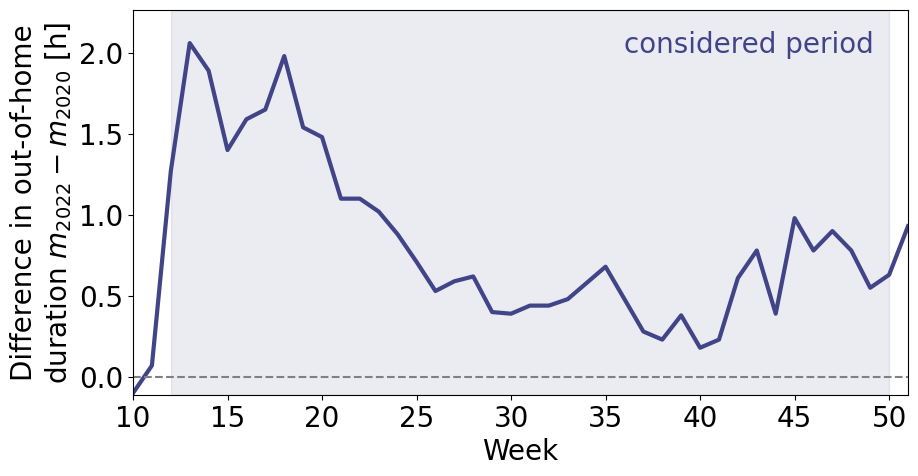

In [47]:
# plot difference between 2020 and 2022
fig, ax = plt.subplots(figsize=(10, 5))
weeks = mobility_df_2020_full.week.values
mobility_difference = mobility_data_2022_full.values - mobility_data_2020_full.values
ax.plot(
    weeks, 
    mobility_difference, 
    linewidth=3,
    color=color_m_obs
    )
ax.set_xlabel("Week")
ax.set_xlim(weeks[0], weeks[-1])
ax.set_ylim(1.1 * mobility_difference.min(), 1.1 * mobility_difference.max())
ax.set_ylabel("Difference in out-of-home\nduration $m_{2022}-m_{2020}$ [h]")
ax.hlines(0, weeks[0], weeks[-1], linestyle="--", color="gray")
ax.axvspan(weeks[2], weeks[-2], alpha=0.1, color=color_m_obs)
ax.text(weeks[26], 2, "considered period", color=color_m_obs)

### Data arrays for model

In [6]:
# get dates
mobility_dates = mobility_df.index.values
mobility_dates_2020 = mobility_dates[mobility_dates < np.datetime64('2020-12-20')]
mobility_dates_2020 = mobility_dates_2020[mobility_dates_2020 > np.datetime64('2020-03-15')]
mobility_dates_2022 = mobility_dates[mobility_dates < np.datetime64('2022-12-20')]
mobility_dates_2022_shortened = mobility_dates_2022[-len(mobility_dates_2020):]

# get mobility data
mobility_df_2020 = mobility_df.filter(items=mobility_dates_2020, axis=0)
mobility_df_2022 = mobility_df.filter(items=mobility_dates_2022_shortened, axis=0)

mobility_data_2020 = mobility_df_2020["outOfHomeDuration"].to_xarray()
mobility_data_2022 = mobility_df_2022["outOfHomeDuration"].to_xarray()

In [14]:
mobility_data_2020

<xarray.DataArray 'outOfHomeDuration' (date: 39)>
array([5.91, 5.27, 5.58, 5.64, 5.49, 6.06, 5.95, 6.49, 6.47, 6.44, 6.95,
       6.65, 6.95, 7.28, 7.5 , 7.37, 7.32, 7.43, 7.4 , 7.43, 7.49, 7.41,
       7.46, 7.53, 7.58, 7.76, 7.83, 7.58, 7.5 , 7.61, 7.24, 7.2 , 7.02,
       6.75, 6.85, 6.66, 6.7 , 6.9 , 6.75])
Coordinates:
  * date     (date) datetime64[ns] 2020-03-22 2020-03-29 ... 2020-12-13

In [15]:
mobility_data_2022

<xarray.DataArray 'outOfHomeDuration' (date: 39)>
array([7.18, 7.33, 7.47, 7.04, 7.08, 7.71, 7.93, 8.03, 7.95, 7.54, 8.05,
       7.67, 7.83, 7.99, 8.03, 7.96, 7.94, 7.83, 7.79, 7.87, 7.93, 7.89,
       8.04, 8.21, 8.06, 8.04, 8.06, 7.96, 7.68, 7.84, 7.85, 7.98, 7.41,
       7.73, 7.63, 7.56, 7.48, 7.45, 7.38])
Coordinates:
  * date     (date) datetime64[ns] 2022-03-27 2022-04-03 ... 2022-12-18

## Effective Reproduction Number

In [15]:
path_R = "data/R/Germany/R_eff_Germany.csv"
R_df = pd.read_csv(path_R, index_col=1, parse_dates=True)

In [18]:
# weekly average placed on Sunday
df = utils.weekly_formatting(R_df, mobility_dates_2020)
df = utils.transform_data(df["R_eff median"])
R_data = df.to_xarray()

# plot R data
#R_data.plot()

## Our World in Data

In [48]:
owid = cov19.data_retrieval.OWD()
owid.download_all_available_data()
owid.data.columns

INFO     [covid19_inference.covid19_inference.data_retrieval.retrieval] Successfully loaded OurWorldinData.csv.gz from C:\Users\iftek\AppData\Local\Temp/covid19_data/, skipping download.


Index(['iso_code', 'continent', 'country', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       'total_vacc

### Hospitalisation

In [20]:
H_data = owid._filter(
    value = "weekly_hosp_admissions_per_million", 
    country="Germany", 
    )
H_data = utils.weekly_formatting(H_data, mobility_dates_2020)
H_data = H_data.to_xarray()
#H_data

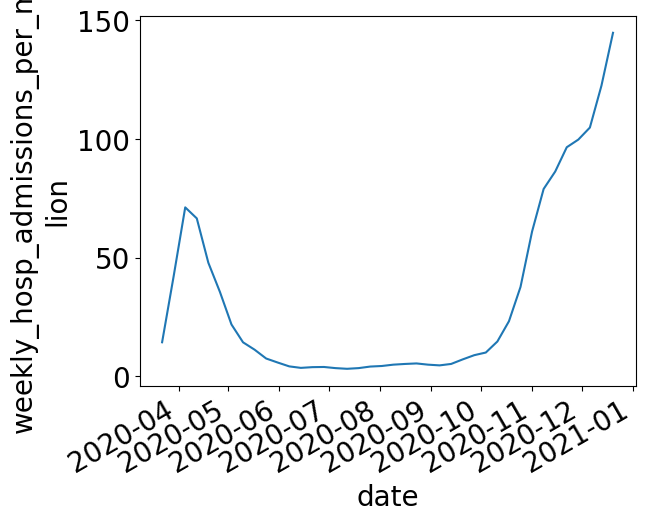

In [14]:
H_data.plot()

### ICU

In [21]:
ICU_data = owid._filter(
    value = "icu_patients_per_million", 
    country="Germany", 
    #data_begin=mobility_dates_2020[0], 
    #data_end=mobility_dates_2020[-1]
    )
ICU_data = utils.weekly_formatting(ICU_data, mobility_dates_2020)
ICU_data = utils.transform_data(ICU_data).to_xarray()
#ICU_data

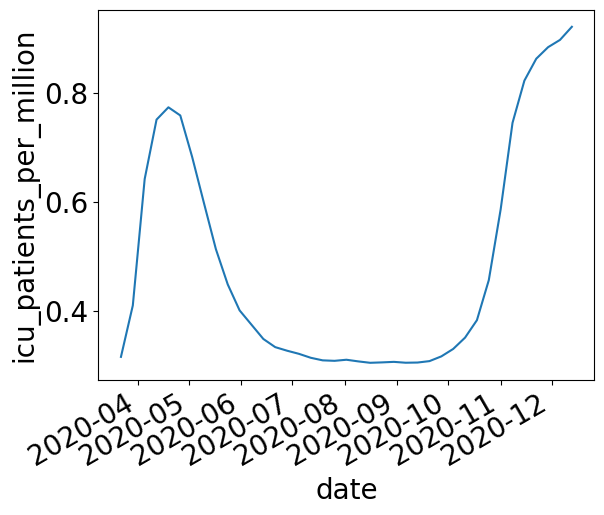

In [28]:
# plot ICU data
ICU_data.plot()

### Cases

In [22]:
case_data = owid._filter(
    value = "new_cases_smoothed_per_million", 
    country="Germany", 
    )
case_data = utils.weekly_formatting(case_data, mobility_dates_2020)
case_data = utils.transform_data(case_data).to_xarray()

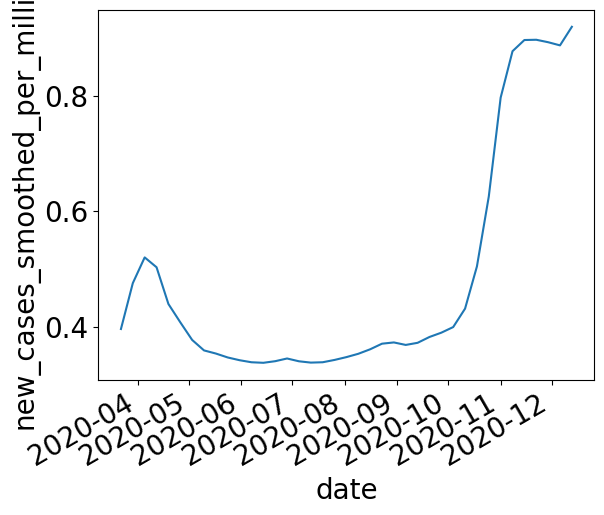

In [31]:
# plot case data
case_data.plot()

## Non-pharmaceutical interventions (NPIs)

In [8]:
stay_at_home_2020 = utils.get_NPI_data("data/NPIs/stay-at-home-covid.csv", mobility_dates_2020)
movement_restrictions_2020 = utils.get_NPI_data("data/NPIs/internal-movement-covid.csv", mobility_dates_2020)
public_transport_2020 = utils.get_NPI_data("data/NPIs/public-transport-covid.csv", mobility_dates_2020)

c:\Users\iftek\Documents\MPI\mobility inference\mobility_inference\utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()
c:\Users\iftek\Documents\MPI\mobility inference\mobility_inference\utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()
c:\Users\iftek\Documents\MPI\mobility inference\mobility_inference\utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for

In [36]:
def format_x_axis(ax_in, x_in, last=False, n_xticks=6):
    dates = [pd.to_datetime(str(x)) for x in x_in]

    # get x tick locations
    xticks = np.linspace(0, len(x_in)-1, n_xticks, dtype=int)
    # get x tick labels
    #xticklabels = [x_in[i] for i in xticks]
    xticklabels = [dates[i].strftime("%d %b") for i in xticks]
    # set x ticks
    ax_in.set_xticks([x_in[i]for i in xticks])
    # increase x tick length
    ax_in.tick_params(axis="x", length=10)
    if last:
        # set x tick labels
        ax_in.set_xticklabels(xticklabels)
        ax_in.set_xlabel("Year 2020")
    else:
        # set x tick labels
        ax_in.set_xticklabels([])
    # set x limits
    ax_in.set_xlim(x_in[0], x_in[-1])

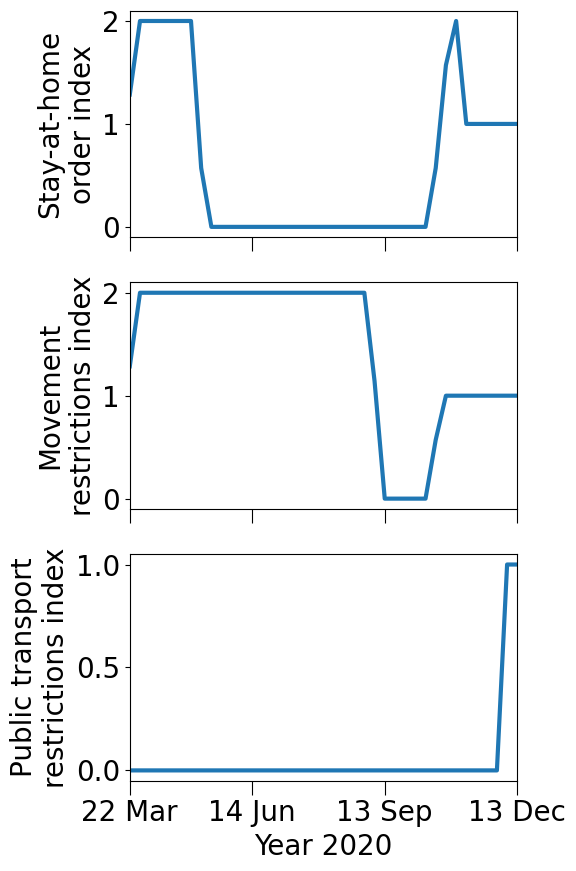

In [38]:
fig, axs = plt.subplots(3, 1, figsize=(5, 10), sharex=True)
n_xticks = 4

ax = axs[0]
ax.plot(mobility_dates_2020, stay_at_home_2020, linewidth=3)
ax.set_ylabel("Stay-at-home\norder index")
format_x_axis(ax, mobility_dates_2020, n_xticks=n_xticks)

ax = axs[1]
ax.plot(mobility_dates_2020, movement_restrictions_2020, linewidth=3)
ax.set_ylabel("Movement\nrestrictions index")
format_x_axis(ax, mobility_dates_2020, n_xticks=n_xticks)

ax = axs[2]
ax.plot(mobility_dates_2020, public_transport_2020, linewidth=3)
ax.set_ylabel("Public transport\nrestrictions index")
format_x_axis(ax, mobility_dates_2020, last=True, n_xticks=n_xticks)

Text(0.5, 1.0, 'Mobility-related non-pharmaceutical\ninterventions in Germany\n(higher index = stricter)')

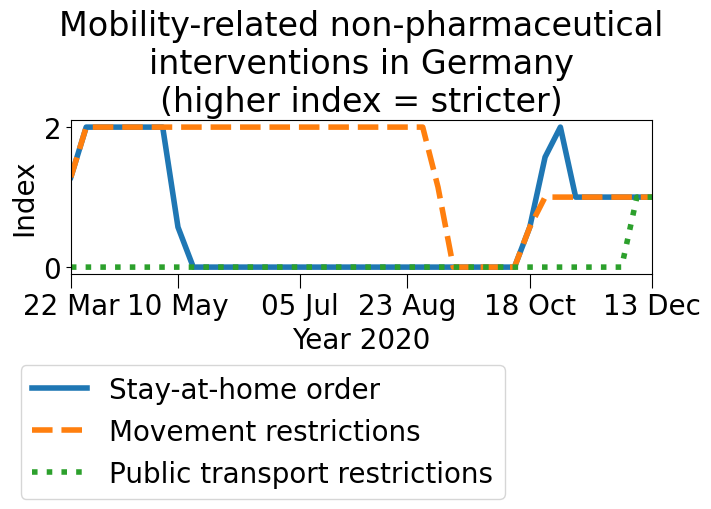

In [65]:
fig, ax = plt.subplots(figsize=(7.5, 2))
linewidth = 4
ax.plot(mobility_dates_2020, stay_at_home_2020, linewidth=linewidth, label="Stay-at-home order")
ax.plot(mobility_dates_2020, movement_restrictions_2020, linewidth=linewidth, label="Movement restrictions", linestyle="--")
ax.plot(mobility_dates_2020, public_transport_2020, linewidth=linewidth, label="Public transport restrictions", linestyle=":")
ax.set_ylabel("Index")
format_x_axis(ax, mobility_dates_2020, last=True)
ax.legend(bbox_to_anchor=(0.77, -0.5))
ax.set_title("Mobility-related non-pharmaceutical\ninterventions in Germany\n(higher index = stricter)")

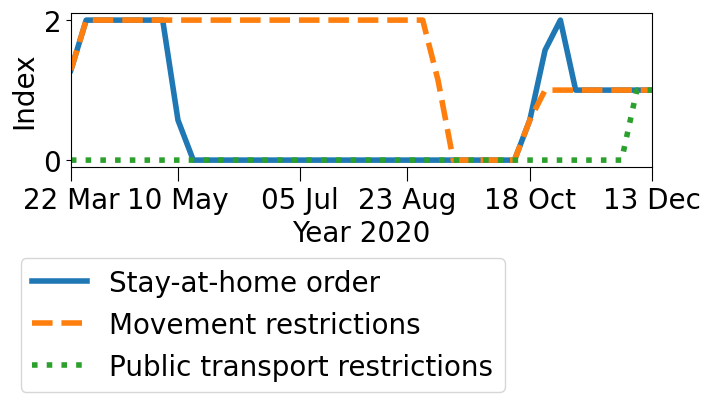

In [66]:
fig, ax = plt.subplots(figsize=(7.5, 2))
linewidth = 4
ax.plot(mobility_dates_2020, stay_at_home_2020, linewidth=linewidth, label="Stay-at-home order")
ax.plot(mobility_dates_2020, movement_restrictions_2020, linewidth=linewidth, label="Movement restrictions", linestyle="--")
ax.plot(mobility_dates_2020, public_transport_2020, linewidth=linewidth, label="Public transport restrictions", linestyle=":")
ax.set_ylabel("Index")
format_x_axis(ax, mobility_dates_2020, last=True)
ax.legend(bbox_to_anchor=(0.77, -0.5))
#ax.set_title("Mobility-related non-pharmaceutical\ninterventions in Germany\n(higher index = stricter)")

c:\Users\iftek\Documents\MPI\mobility inference\mobility_inference\utils.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df = df.resample("7D").mean()


<AxesSubplot: xlabel='Day'>

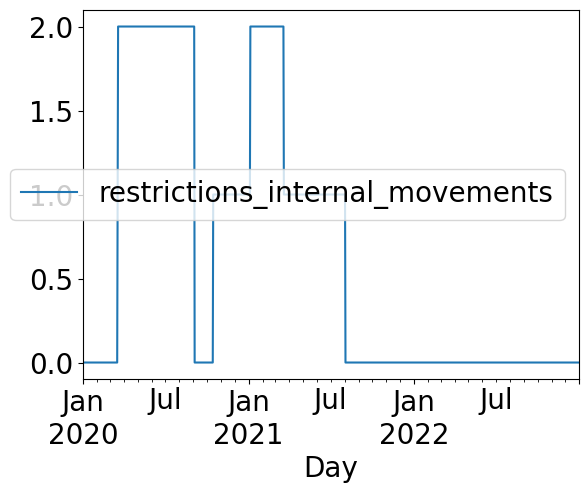

In [63]:
df_movement_restrictions = pd.read_csv("data/NPIs/internal-movement-covid.csv", parse_dates=True, index_col=2)
df_movement_restrictions = df_movement_restrictions[df_movement_restrictions["Entity"] == "Germany"]

# plot movement restrictions
df_movement_restrictions.plot()

<AxesSubplot: xlabel='Day'>

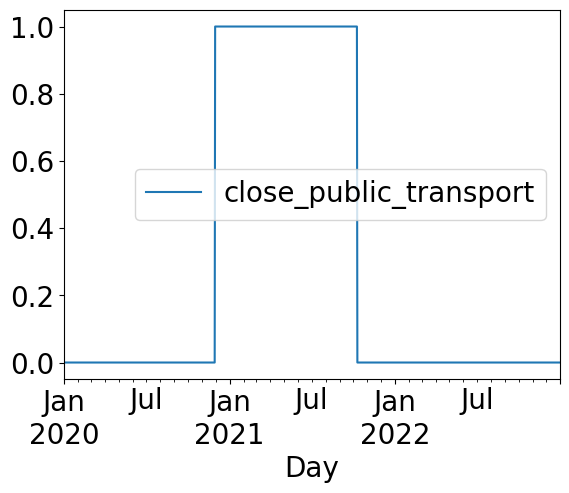

In [66]:
df_public_transport = pd.read_csv("data/NPIs/public-transport-covid.csv", parse_dates=True, index_col=2)
df_public_transport = df_public_transport[df_public_transport["Entity"] == "Germany"]

# plot movement restrictions
df_public_transport.plot()

<AxesSubplot: xlabel='Day'>

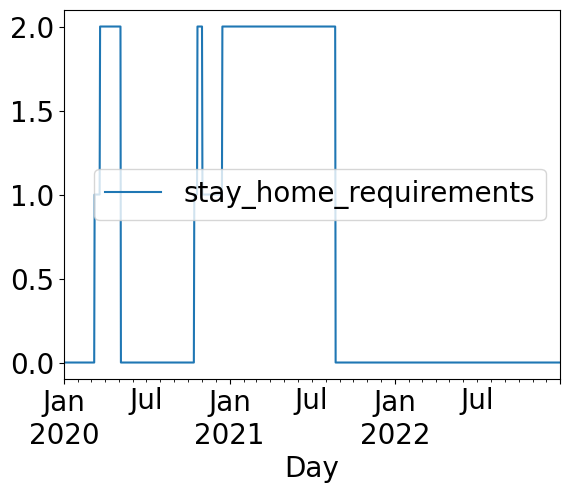

In [70]:
df_stay_at_home = pd.read_csv("data/NPIs/stay-at-home-covid.csv", parse_dates=True, index_col=2)
df_stay_at_home = df_stay_at_home[df_stay_at_home["Entity"] == "Germany"]

# plot movement restrictions
df_stay_at_home.plot()

## Visualise and compare

(12.0, 51.0)

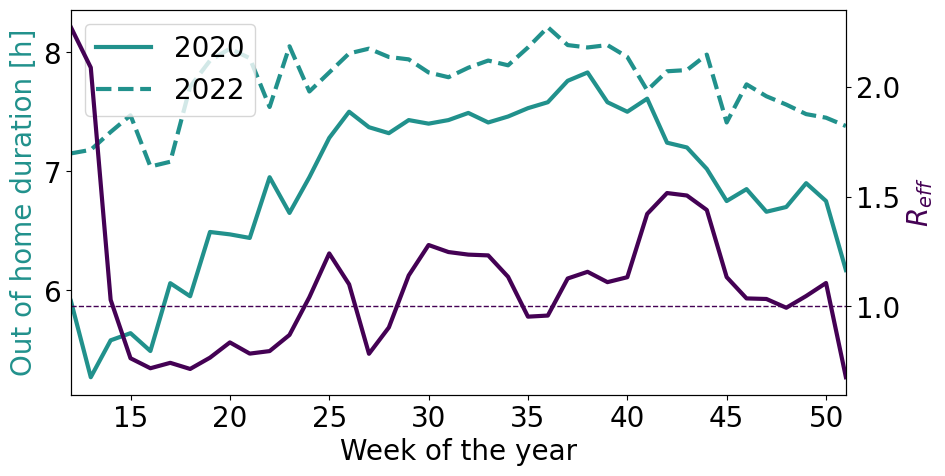

In [10]:
# plot mobility and R data
color_R = colormap(0)
color_m = colormap(0.5)

min_x = mobility_df_2020["week"].min()
max_x = mobility_df_2020["week"].max()

fig, ax = plt.subplots(figsize=(10, 5))
ax_R = ax.twinx()
ax.plot(mobility_df_2020["week"], mobility_df_2020["outOfHomeDuration"], label="2020", linewidth=3, color=color_m_R)
ax.plot(mobility_df_2020["week"], mobility_df_2022["outOfHomeDuration"], label="2022", linewidth=3, color=color_m_base, linestyle="--")
ax_R.plot(mobility_df_2020["week"], R_df_weekly_shortened["R_eff median"], linewidth=3, color=color_R)
ax_R.hlines(1, min_x, max_x, color=color_R, linestyle="--", linewidth=1)
ax.legend(loc="upper left")
ax.set_xlabel("Week of the year") # THIS IS NOT COMPLETELY CORRECT AS 2022 IS ONLY 51 WEEKS LONG
ax.set_ylabel("Out of home duration [h]", color=color_m)
ax_R.set_ylabel(f"$R_{{eff}}$", color=color_R)
ax.set_xlim(min_x, max_x)